In [1]:
import sys
import os
from pathlib import Path
from copy import deepcopy
project_dir = Path(os.path.abspath('')).parent
sys.path.insert(0, project_dir.as_posix())

from tqdm import trange, tqdm
import numpy as np
import torch
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
from sentence_transformers import SentenceTransformer

%load_ext autoreload
%autoreload 2
import train_dpr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
top_k = [5, 20, 40, 60, 80, 100]
acc_df = pd.DataFrame(columns=["model"] + [f"top-{k}" for k in top_k])


def append_result(model_name, accuracy):
    acc_df.loc[len(acc_df)] = [model_name] + [accuracy[k] for k in top_k]

In [3]:
# ----- MiniMind2-Small-Pretrain -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="pretrain",
    train_bert=False,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, train_ds, test_ds = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=128)
append_result("MiniMind2-Small-Pretrain", acc)

# ----- MiniMind2-Pretrain -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="pretrain",
    hidden_size=768,
    num_hidden_layers=16,
    train_bert=False,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, _, _ = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=128)
append_result("MiniMind2-Pretrain", acc)

# ----- MiniMind-Small-DPR -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="dpr",
    train_bert=False,
    use_wandb=False,
    dtype="float16",
)
model, tokenizer, _, _ = train_dpr.train(args, early_return=1)
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=128)
append_result("MiniMind2-Small-DPR", acc)

# ----- BM25 and SBERT -----
args = train_dpr.TrainArgs(
    save_weight="dpr",
    use_amp=True,
    from_weight="none",
    train_bert=True,
    use_wandb=False,
    dtype="float16",
    dataset="ChineseSquad"
)
_, _, train_ds, test_ds = train_dpr.train(args, early_return=1)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
acc = train_dpr.benchmark_retriever(model, test_ds, top_k=top_k, batch_size=256)

acc_bm25 = train_dpr.benchmark_retriever("bm25", test_ds, top_k=top_k, batch_size=256)
append_result("BM25", acc_bm25)
append_result("SBERT", acc)

所加载Model可训练参数：25.830 百万


100%|██████████| 6/6 [00:01<00:00,  3.04it/s]


所加载Model可训练参数：104.031 百万


100%|██████████| 6/6 [00:05<00:00,  1.00it/s]


所加载Model可训练参数：25.830 百万


...

Split strings:   0%|          | 0/199 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/199 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/199 [00:00<?, ?it/s]

Split strings:   0%|          | 0/199 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/199 [00:00<?, ?it/s]

In [10]:
acc_df
acc_df_new = pd.DataFrame(columns=acc_df.columns)
for i in [3, 4, 0, 1, 2]:
    acc_df_new.loc[len(acc_df_new)] = acc_df.loc[i]
acc_df = acc_df_new
acc_df

,model,top-5,top-20,top-40,top-60,top-80,top-100
0,BM25,0.045226,0.120603,0.221106,0.321608,0.41206,0.512563
1,SBERT,0.894472,0.984925,0.994975,1.0,1.0,1.0
2,MiniMind2-Small-Pretrain,0.115328,0.230657,0.308029,0.363504,0.427737,0.465693
3,MiniMind2-Pretrain,0.131387,0.236496,0.306569,0.376642,0.417518,0.452555
4,MiniMind2-Small-DPR,0.154745,0.293431,0.366423,0.408759,0.456934,0.49635


In [12]:
acc_df_show = deepcopy(acc_df)
for i in range(len(acc_df_show)):
    for k in top_k:
        acc_df_show.at[i, f"top-{k}"] = f"{acc_df_show.at[i, f'top-{k}']:.3f}"
acc_df_show

,model,top-5,top-20,top-40,top-60,top-80,top-100
0,BM25,0.045,0.121,0.221,0.322,0.412,0.513
1,SBERT,0.894,0.985,0.995,1.000,1.000,1.000
2,MiniMind2-Small-Pretrain,0.115,0.231,0.308,0.364,0.428,0.466
3,MiniMind2-Pretrain,0.131,0.236,0.307,0.377,0.418,0.453
4,MiniMind2-Small-DPR,0.155,0.293,0.366,0.409,0.457,0.496


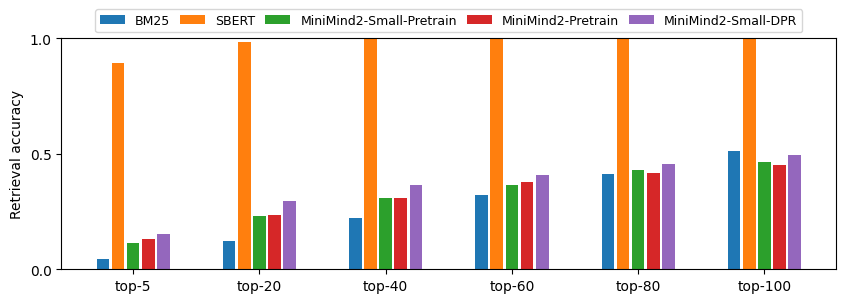

In [16]:
fig, ax = plt.subplots(figsize=(10, 3))
mpl.rcParams["font.size"] = 10
for i in range(len(acc_df)):
    model, *values = acc_df.loc[i].tolist()
    xs = np.arange(len(values))
    xs = xs + (i - 2) * 0.12
    ax.bar(xs, values, label=model, width=0.1)
ax.set_ylim(0, 1)
ax.set_ylabel("Retrieval accuracy")
ax.set_yticks([0, 0.5, 1])
ax.set_xticks(np.arange(len(values)))
ax.set_xticklabels([f"top-{k}" for k in top_k])
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    fontsize=9,
    ncol=len(acc_df),
    columnspacing=0.8,
)